# Model 1 — robust temperature-only baseline

Final baseline model:

\[
y_i=\log(PR_i)
\]

\[
y_i \sim StudentT(\nu,\mu_i,\sigma)
\]

\[
\mu_i=\alpha+\beta_T x_{T,i}
\]

where:

\[
x_T=\frac{T_m-25}{10}
\]

This model is not artificially weakened. It already uses a Student-t likelihood.  
Model 2 should differ mainly by adding daily offsets.

In [18]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Load moderate dataset

In [ ]:
DATA_PATH = "Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_moderate.csv"
df = pd.read_csv(DATA_PATH)

print("Using clean data:", DATA_PATH)

STAN_MODEL_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt.stan")
STAN_PRIOR_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive.stan")

print("Using data:", DATA_PATH)
print("Raw shape:", df.shape)
print(df.columns.tolist())

required = ["logPR", "PR", "x_T", "T_module_C"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()

if "day_id" in df.columns:
    df["day_id"] = pd.factorize(df["day_id"])[0] + 1

print("Model shape:", df.shape)
df[["logPR", "PR", "x_T", "T_module_C"]].head()

Using clean data: Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_moderate.csv
Using data: Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_moderate.csv
Raw shape: (1486, 15)
['timestamp', 'day', 'day_id', 'month', 'hour', 'logPR', 'PR', 'x_T', 'z_wind', 'T_module_C', 'wind_ms', 'G_POA_Wm2', 'P_DC_kW', 'expected_P_DC_kW', 'power_ratio']
Model shape: (1486, 15)


,logPR,PR,x_T,T_module_C
0,-0.128713,0.879226,3.322,58.22
1,-0.141172,0.868340,3.418,59.18
2,-0.134383,0.874255,3.536,60.36
3,-0.129893,0.878190,3.359,58.59
4,-0.138943,0.870278,3.580,60.80


## 2. Prepare Stan data

In [20]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
N = len(df)

stan_data = {"N": N, "y": y, "x_T": x_T}
prior_data = {"N": N, "x_T": x_T}

print("N =", N)
print("x_T range:", x_T.min(), x_T.max())
print("PR range:", df["PR"].min(), df["PR"].max())

N = 1486
x_T range: -0.322 4.087
PR range: 0.513241766948783 1.11252867182318


## 3. EDA

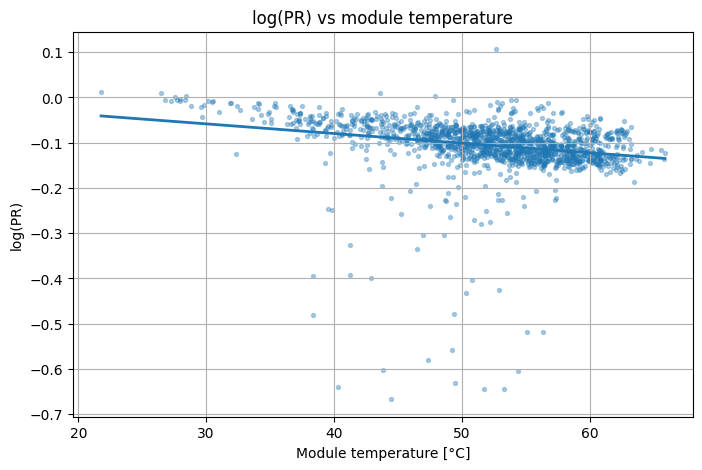

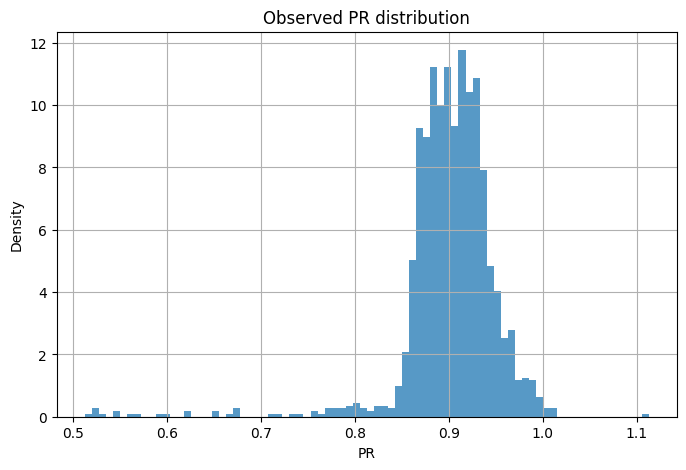

In [21]:
plt.figure()
plt.scatter(df["T_module_C"], df["logPR"], s=8, alpha=0.35)
p = np.polyfit(df["T_module_C"], df["logPR"], 1)
xx = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 200)
plt.plot(xx, np.polyval(p, xx), linewidth=2)
plt.xlabel("Module temperature [°C]")
plt.ylabel("log(PR)")
plt.title("log(PR) vs module temperature")
plt.show()

plt.figure()
plt.hist(df["PR"], bins=80, density=True, alpha=0.75)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Observed PR distribution")
plt.show()

## 4. Prior predictive check

In [22]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))
prior_fit = prior_model.sample(
    data=prior_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [5, 50, 95]))
print("Prior beta_T:", np.percentile(beta_T_prior, [5, 50, 95]))
print("Prior sigma:", np.percentile(sigma_prior, [5, 50, 95]))
print("Prior nu:", np.percentile(nu_prior, [5, 50, 95]))
print("Prior predictive PR:", np.percentile(PR_prior.flatten(), [1, 5, 50, 95, 99]))

ValueError: no such file /workspace/model_1_temperature_studentt_prior_predictive.stan

In [ ]:
plt.figure()
plt.hist(PR_prior.flatten(), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.5)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (name, samples) in zip(
    axes,
    [("alpha", alpha_prior), ("beta_T", beta_T_prior), ("sigma", sigma_prior), ("nu", nu_prior)]
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Fit Model 1

In [ ]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

## 6. Diagnostics

In [ ]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "sigma", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

## 7. Posterior analysis

In [ ]:
alpha = fit.stan_variable("alpha")
beta_T = fit.stan_variable("beta_T")
sigma = fit.stan_variable("sigma")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")

effect_10C_pct = 100 * (np.exp(beta_T) - 1)
effect_1C_pct = 100 * (np.exp(beta_T / 10) - 1)

print(f"P(beta_T < 0 | data) = {np.mean(beta_T < 0):.4f}")
print("beta_T percentiles:", np.percentile(beta_T, [5, 50, 95]))
print("Effect per +10°C [%]:", np.percentile(effect_10C_pct, [5, 50, 95]))
print("Effect per +1°C [%]:", np.percentile(effect_1C_pct, [5, 50, 95]))
print("sigma percentiles:", np.percentile(sigma, [5, 50, 95]))
print("nu percentiles:", np.percentile(nu, [5, 50, 95]))

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior beta_T", beta_T, "beta_T", True),
    ("Effect of +10°C on PR", effect_10C_pct, "Percent change [%]", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]
for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Posterior predictive check

In [ ]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure()
plt.hist(PR_pred.flatten(), bins=100, density=True, alpha=0.55, label="Posterior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.0)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.legend()
plt.show()

## 9. Residual diagnostics — motivation for Model 2

In [ ]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_mu_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

if "day_id" in df_check.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("PR residual = observed - predicted")
    plt.title("Model 1 residuals by day")
    plt.show()

    daily_res = df_check.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
    plt.figure(figsize=(10, 5))
    plt.plot(daily_res["day_id"], daily_res["daily_mean_residual"], "o-")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("Daily mean residual PR")
    plt.title("Daily mean residuals — motivation for daily-offset Model 2")
    plt.show()
else:
    print("No day_id column found, skipping daily residual diagnostics.")

## 10. Save ArviZ object

In [ ]:
idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)

with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved: idata_model1_temperature_studentt.pkl")

## Interpretation

Model 1 is a robust temperature-only baseline. It estimates the linear temperature-related loss in normalized PV performance using a Student-t likelihood. If daily residual diagnostics still show systematic day-to-day structure, then Model 2 with daily offsets is justified.